# Sheet 05 - Variational Autoencoders

Introduction to Deep Learning - Summer Semester 2026

Ulf Krumnack & Robin Rawiel - Universität OsnabrückDue: May 24, 2026

In this exercise sheet you will focus on the VAE part of generative
learning from lecture 07. The goal is to connect the probabilistic ideas
from the lecture and script to a compact MNIST implementation. You will
derive the ELBO ingredients, implement a VAE with the reparameterization
trick, and inspect how reconstruction quality and latent-space
regularization interact in practice.

## Task 1: Theory and VAE Intuition \[6 points\]

### 1.1 Latent Variable Models and the ELBO \[2 points\]

1.  What is a **latent variable model**? Write down the marginal
    likelihood of an observation $x$ in terms of a latent variable $z$.

2.  Why is the marginal likelihood typically intractable for deep
    generative models, and how does the **Evidence Lower Bound (ELBO)**
    $\log p(x) \geq \mathbb{E}_{q_\phi(z\mid x)}[\log p_\theta(x\mid z)] - D_{\mathrm{KL}}\bigl(q_\phi(z\mid x) \| p(z)\bigr)$
    address this? Explain the role of the reconstruction term and the KL
    term.

### 1.2 Reparameterization and Stochastic Layers \[2 points\]

1.  Why can we not directly backpropagate through a naive sample
    $z \sim \mathcal{N}(\mu, \sigma^2)$ inside a VAE, and how does the
    **reparameterization trick** $z = \mu + \sigma \odot \epsilon$ with
    $\epsilon \sim \mathcal{N}(0, I)$ make gradient-based training
    possible?
    
    Answer: You cant really do that, how do you take derivate from random result. By changing input of random procedure you end up having random result. So the idea is to put a leash on randomness and introduce the noise. The reparameterization
    trick fixes this by sampling $\epsilon \sim \mathcal{N}(0, I)$ externally as a
    fixed constant, then computing $z = \mu + \sigma \times \epsilon$
    deterministically.

2.  Why does the encoder output a mean and a log-variance instead of a
    single deterministic latent vector?

    Answer: A standard autoencoder maps each image to one fixed point z in latent
    space. This creates vast empty regions between training points — if you
    sample from those regions, the decoder produces garbage. By outputting
    a distribution (mean μ and variance σ²), the encoder expresses
    uncertainty about the exact latent location. This forces overlapping
    blobs across the latent space, filling the holes and making random
    sampling reliable for generation.


### 1.3 Reconstruction, Regularization, and Blurriness \[2 points\]

The lecture and script discuss blurriness mainly for Gaussian decoders
and squared-error reconstruction. The important idea for this task is
the same more generally: pixel-wise losses encourage averaging when the
model is uncertain about fine detail.

1.  What does the KL term encourage in the latent space of a VAE, and
    why can a standard VAE produce blurry reconstructions or samples
    when the decoder is trained with a pixel-wise reconstruction term?

2.  What is the main idea of a **VQ-VAE**, and why can discrete latent
    codes help reduce blur?

## Common Setup

The next two code cells provide the shared setup used in the
generative-model experiments below. To keep the runtime manageable on
your laptops, we work on subsets of MNIST rather than the full dataset.

In this part you should:

- load the MNIST subsets and create the data loaders,
- complete the two helper functions `scale_to_tanh` and `show_grid`, and
- run the second cell to print the dataset shapes and display a few
  example digits.

In [52]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()
full_train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)
full_test_dataset = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)

train_subset = Subset(full_train_dataset, range(8000))
test_subset = Subset(full_test_dataset, range(1000))

train_loader = DataLoader(train_subset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=256, shuffle=False)


def scale_to_tanh(images):
    """Map images from [0, 1] to [-1, 1] for the GAN."""
    return images * 2.0 - 1.0


def show_grid(images, title, nrow=8, normalize=False, value_range=None):
    """Utility function to display image batches."""
    grid = torchvision.utils.make_grid(
        images, nrow=nrow, normalize=normalize, value_range=value_range, pad_value=0.5
    )
    plt.figure(figsize=(12, max(2, images.shape[0] // nrow)))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

Train subset: 8000 samples
Test subset:  1000 samples
Batch shape: torch.Size([128, 1, 28, 28])  |  dtype: torch.float32  |  range: [0.00, 1.00]


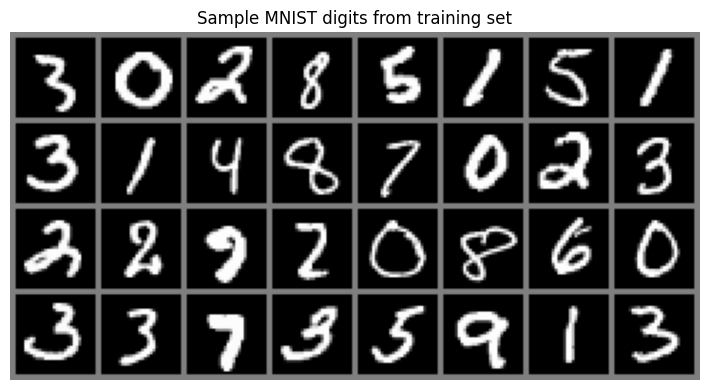

In [53]:
print(f"Train subset: {len(train_subset)} samples")
print(f"Test subset:  {len(test_subset)} samples")

images, labels = next(iter(train_loader))
print(f"Batch shape: {images.shape}  |  dtype: {images.dtype}  |  range: [{images.min():.2f}, {images.max():.2f}]")

show_grid(images[:32], title="Sample MNIST digits from training set")

## Task 2: VAE on MNIST \[10 points\]

**Learning objectives:**

- Implement a VAE with the reparameterization trick and ELBO loss
- Train it on MNIST and inspect reconstructions, prior samples, and
  interpolations
- Visualize the learned latent space on the test set

Tip: get the VAE working first and make sure the loss decreases before
you move on to the visualizations. The later subtasks reuse the same
trained model and are mainly there to help you interpret what the VAE
has learned.

### 2.1 VAE Architecture \[2 points\]

Implement a VAE with a fully connected encoder and decoder. The encoder
should predict both the latent mean $\mu$ and the log-variance
$\log \sigma^2$.

In particular, complete the following parts:

- define the shared encoder network,
- add one linear layer for `mu` and one for `logvar`,
- implement the reparameterization step, and
- complete `decode` and `forward` so that the model returns
  `(x_hat, mu, logvar)`.

After that, instantiate the model and print it once to check that the
architecture looks sensible.

In [54]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, latent_dim=16):
        super().__init__()
        self.latent_dim = latent_dim

        # TODO 1: Define self.encoder_net using nn.Sequential
        #   - Linear(input_dim → hidden_dim), ReLU
        #   - Linear(hidden_dim → hidden_dim), ReLU
        self.encoder_net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )

        # TODO 2: Define two separate linear heads (no activation):
        #   - self.fc_mu:     hidden_dim → latent_dim  (predicts mean)
        #   - self.fc_logvar: hidden_dim → latent_dim  (predicts log-variance)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # TODO 3: Define self.decoder_net using nn.Sequential
        #   - Linear(latent_dim → hidden_dim), ReLU
        #   - Linear(hidden_dim → hidden_dim), ReLU
        #   - Linear(hidden_dim → input_dim), Sigmoid  ← keeps output in [0,1]
        self.decoder_net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def encode(self, x):
        # TODO 4: Pass x through encoder_net, then return (fc_mu(h), fc_logvar(h))
        x = self.encoder_net(x)
        return self.fc_mu(x), self.fc_logvar(x)

    def reparameterize(self, mu, logvar):
        """Sample z = mu + std * eps with eps ~ N(0, I)."""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(mu)
        z = mu + std * eps
        return z

    def decode(self, z):
        # TODO 6: Pass z through decoder_net and return the result
        return self.decoder_net(z)

    def forward(self, x):
        # TODO 7: Flatten x to shape (batch, 784) using x.view(x.size(0), -1)
        #         Call encode to get mu, logvar
        #         Call reparameterize to get z
        #         Call decode to get x_hat
        #         Return (x_hat, mu, logvar)
        x = x.view(x.size(0), -1)
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar

In [55]:
model = VAE()

### 2.2 ELBO Loss on MNIST \[2 points\]

Implement the ELBO loss for this MNIST setup.

In the lecture and script, the reconstruction term was motivated through
a Gaussian decoder, which leads to squared error. Here we instead use a
Bernoulli-style decoder with a sigmoid output and binary cross-entropy,
because MNIST pixels are normalized to $[0, 1]$ and are close to binary.
The ELBO structure stays the same; only the observation model changes.

Your function should return three values:

- the total ELBO loss used for training,
- the reconstruction term, and
- the KL term.

You will use these three values again in the next task to plot the
training curves.

In [56]:
def vae_loss(x_hat, x, mu, logvar, beta=1.0):
    """Return total loss, reconstruction loss, and KL divergence."""
    # TODO 1: Flatten x to (batch, 784) — same shape as x_hat
    #         x_flat = x.view(x.size(0), -1)
    x_flat = x.view(x.size(0), -1)
    # TODO 2: Compute reconstruction loss using BCE
    #         Use F.binary_cross_entropy(x_hat, x_flat, reduction='sum')
    #         'sum' adds up the loss over all pixels and all samples in the batch
    recon_loss = F.binary_cross_entropy(x_hat, x_flat, reduction='sum')
    # TODO 3: Compute KL divergence between learned distribution and N(0, I)
    #         Closed-form formula: -0.5 * sum(1 + logvar - mu² - exp(logvar))
    #         Use .sum() to sum over latent dimensions and batch
    #         Hint: mu ** 2 gives you mu squared element-wise
    kl_loss = -0.5 * torch.sum(1 + logvar - mu**2 - torch.exp(logvar))
    # TODO 4: Compute total loss = recon_loss + beta * kl_loss
    #         beta=1.0 is standard VAE; beta>1 is beta-VAE (stronger regularization)
    total_loss = recon_loss + beta * kl_loss
    # TODO 5: Return (total_loss, recon_loss, kl_loss)
    return (total_loss, recon_loss, kl_loss)

### 2.3 Train and Inspect the VAE \[3 points\]

First complete the training function `train_vae`. Then use it to train
the model and inspect what it has learned.

Your final result in this task should include all of the following:

- a plot of the total, reconstruction, and KL losses over epochs,
- a reconstruction plot comparing original and reconstructed test
  images,
- a grid of samples drawn from the prior, and
- one latent interpolation between two test digits.

When you run the plotting cell, check whether the reconstructions are
recognisable and whether the interpolation changes smoothly.

In [57]:
def train_vae(model, loader, epochs=10, lr=1e-3, beta=1.0):
    # TODO 1: Create an Adam optimizer for model.parameters() with the given lr
    optimizer = optim.Adam(model.parameters(), lr=lr)
    # TODO 2: Set model to training mode with model.train()
    model.train()
    # TODO 3: Create three empty lists to track losses per epoch:
    history_total, history_recon, history_kl = [], [], []
    # TODO 4: Loop over epochs. Inside each epoch:
    for epoch in range(epochs):
        #   a) Initialize epoch accumulators to 0
        epoch_total, epoch_recon, epoch_kl = 0, 0, 0
        #   b) Loop over batches in loader
        for images, _ in loader:
            #   c) Move images to device
            images = images.to(device)
            #   d) Zero the gradients
            optimizer.zero_grad()
            #   e) Run forward pass
            x_hat, mu, logvar = model(images)
            #   f) Compute loss
            total, recon, kl = vae_loss(x_hat, images, mu, logvar, beta)
            #   g) Backpropagate
            total.backward()
            #   h) Update weights
            optimizer.step()
            #   i) Accumulate the three loss values
            epoch_total += total.item()
            epoch_recon += recon.item()
            epoch_kl += kl.item()

        # TODO 5: Append mean losses to history lists (divide by dataset size)
        n = len(loader.dataset)
        history_total.append(epoch_total / n)
        history_recon.append(epoch_recon / n)
        history_kl.append(epoch_kl / n)

        # TODO 6: Print epoch progress
        print(f"Epoch {epoch+1}/{epochs} | Total: {epoch_total/n:.2f} | Recon: {epoch_recon/n:.2f} | KL: {epoch_kl/n:.2f}")

    # TODO 7: Return history
    return history_total, history_recon, history_kl

Epoch 1/10 | Total: 256.71 | Recon: 254.27 | KL: 2.44
Epoch 2/10 | Total: 199.49 | Recon: 197.43 | KL: 2.05
Epoch 3/10 | Total: 191.25 | Recon: 187.73 | KL: 3.52
Epoch 4/10 | Total: 182.55 | Recon: 177.62 | KL: 4.93
Epoch 5/10 | Total: 171.27 | Recon: 163.80 | KL: 7.47
Epoch 6/10 | Total: 157.86 | Recon: 147.89 | KL: 9.97
Epoch 7/10 | Total: 150.74 | Recon: 139.65 | KL: 11.09
Epoch 8/10 | Total: 145.09 | Recon: 133.05 | KL: 12.04
Epoch 9/10 | Total: 140.92 | Recon: 128.24 | KL: 12.68
Epoch 10/10 | Total: 137.03 | Recon: 123.85 | KL: 13.18


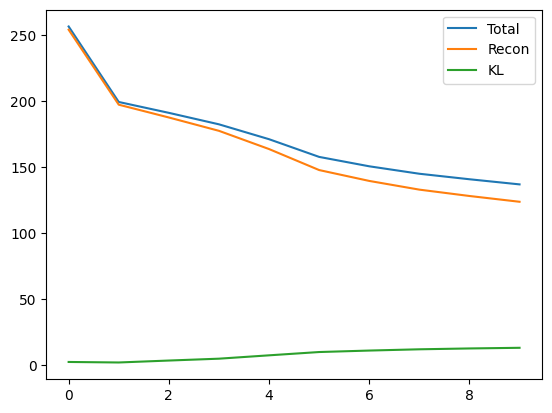

In [58]:
# TODO: Your solution here
model = VAE()
history_total, history_recon, history_kl = train_vae(model, train_loader)

plt.plot(history_total, label='Total')
plt.plot(history_recon, label='Recon')
plt.plot(history_kl, label='KL')
plt.legend()
plt.show()

### 2.4 Visualize the Latent Space \[1 point\]

Encode the test set, keep the latent means `mu`, and make a scatter plot
of the first two latent coordinates colored by digit label.

Because the latent dimension is 16, this is only a two-dimensional
projection. Still, it is a useful sanity check for whether nearby digits
occupy nearby regions in latent space.

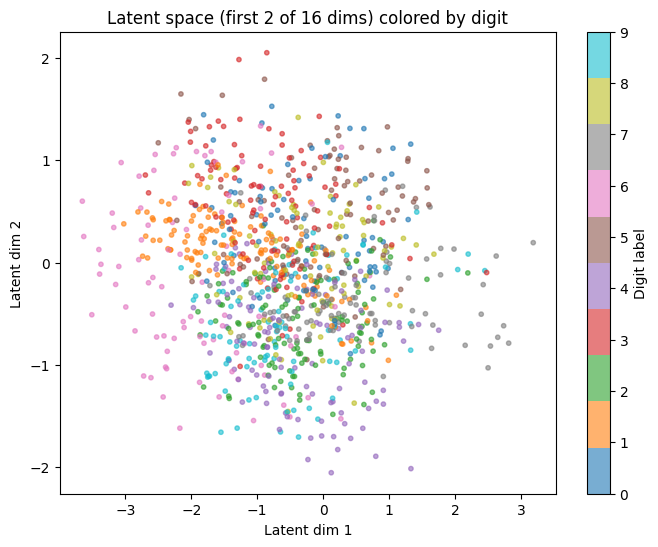

In [59]:
model.eval()
all_mu, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        mu, _ = model.encode(images.view(images.size(0), -1))
        all_mu.append(mu.cpu())
        all_labels.append(labels)

mu = torch.cat(all_mu)
labels = torch.cat(all_labels)

plt.figure(figsize=(8, 6))
plt.scatter(mu[:, 0], mu[:, 1], c=labels, cmap='tab10', alpha=0.6, s=10)
plt.colorbar(label='Digit label')
plt.xlabel('Latent dim 1')
plt.ylabel('Latent dim 2')
plt.title('Latent space (first 2 of 16 dims) colored by digit')
plt.show()

### 2.5 Interpret the VAE Results \[2 points\]

Answer the following questions after inspecting your reconstructions,
prior samples, interpolation, and latent scatter plot:

1.  Which plots indicate that the latent space is structured well enough
    for interpolation and sampling?

    **Answer:** The scatter plot of the latent space shows digit clusters, same digits
    group together in latent space. This suggests that nearby points decode to similar
    images, which is a necessary condition for smooth interpolation. The interpolation
    plot itself is the direct indicator: if the transition between two digits is gradual
    and recognizable, the space is smooth. The prior samples grid also helps, if random
    samples from N(0,I) produce recognizable digits rather than noise, the latent space
    is well-structured. Note that the scatter plot only shows 2 of 16 dimensions, so it
    is a weak signal rather than proof.

2.  Why is binary cross-entropy a reasonable reconstruction loss for
    this MNIST experiment, even though the lecture and script often
    discuss squared error, and what qualitative change would you expect
    if $\beta$ in the ELBO were increased strongly?

    **Answer:** BCE is reasonable because MNIST pixels are near 0 or 1 (black background,
    white strokes). BCE treats each pixel as a probability of being "on", which matches
    the near-binary nature of the data. MSE would treat pixel values as continuous
    measurements on a smooth scale, which does not reflect how MNIST actually looks.

    If $\beta$ were increased strongly, the KL term would dominate the loss, forcing the
    encoder to push all latent distributions very close to N(0,I). This means all mu
    values collapse toward 0 and the encoder loses the ability to encode fine image
    details. The result is blurrier, more generic reconstructions, a better structured
    latent space but at the cost of reconstruction quality.

## Task 3: The $\beta$-VAE Trade-off \[4 points\]

**Learning objectives:**

- Observe the trade-off between reconstruction quality and latent-space
  regularization empirically
- Connect the effect of $\beta$ to the lecture discussion of structured
  latent spaces and blurry samples

For this task, you do not need any additional theory beyond the ELBO
from above. Here, $\beta$ simply rescales the KL term in
$\text{total loss} = \text{reconstruction loss} + \beta \cdot \text{KL loss}$.
Larger $\beta$ means stronger pressure toward the prior, while smaller
$\beta$ lets the model spend more capacity on reconstruction.

### 3.1 Short $\beta$-VAE Experiment \[2 points\]

Train two additional VAEs with clearly different KL weights, for example
$\beta = 0.01$ and $\beta = 8.0$.

In this task you should:

- train both models for a short run,
- plot the reconstruction and KL curves for both settings, and
- compare reconstructions of the same test digits and one grid of prior
  samples from each model.

Use only a few epochs so that the experiment stays lightweight. Reuse
the same `VAE` class and the same `train_vae` function from Task 2. The
only change is the value of `beta` in the loss.

Epoch 1/20 | Total: 259.76 | Recon: 256.94 | KL: 0.35
Epoch 2/20 | Total: 205.80 | Recon: 203.76 | KL: 0.26
Epoch 3/20 | Total: 203.73 | Recon: 199.98 | KL: 0.47
Epoch 4/20 | Total: 202.48 | Recon: 197.61 | KL: 0.61
Epoch 5/20 | Total: 201.83 | Recon: 196.59 | KL: 0.66
Epoch 6/20 | Total: 201.41 | Recon: 195.44 | KL: 0.75
Epoch 7/20 | Total: 200.32 | Recon: 193.46 | KL: 0.86
Epoch 8/20 | Total: 197.93 | Recon: 188.65 | KL: 1.16
Epoch 9/20 | Total: 194.99 | Recon: 183.56 | KL: 1.43
Epoch 10/20 | Total: 192.49 | Recon: 179.62 | KL: 1.61
Epoch 11/20 | Total: 191.40 | Recon: 177.36 | KL: 1.75
Epoch 12/20 | Total: 190.11 | Recon: 175.52 | KL: 1.82
Epoch 13/20 | Total: 189.40 | Recon: 173.84 | KL: 1.94
Epoch 14/20 | Total: 188.38 | Recon: 172.19 | KL: 2.02
Epoch 15/20 | Total: 187.80 | Recon: 170.41 | KL: 2.17
Epoch 16/20 | Total: 186.75 | Recon: 168.47 | KL: 2.28
Epoch 17/20 | Total: 186.09 | Recon: 167.30 | KL: 2.35
Epoch 18/20 | Total: 185.34 | Recon: 165.97 | KL: 2.42
Epoch 19/20 | Total

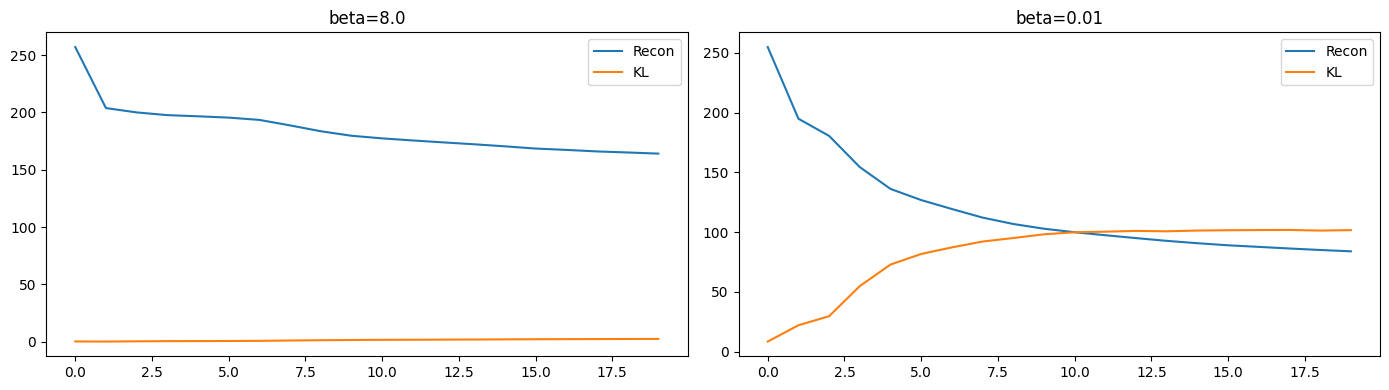

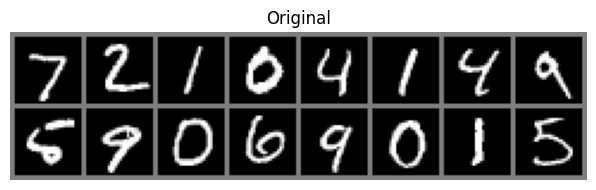

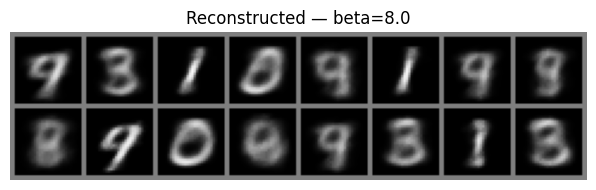

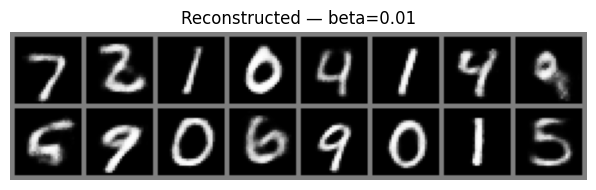

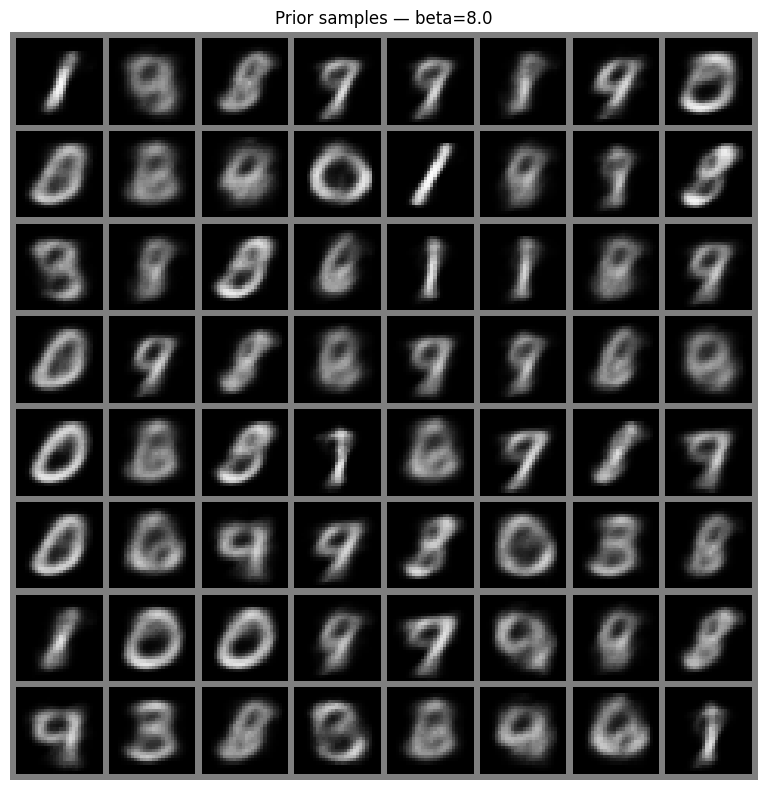

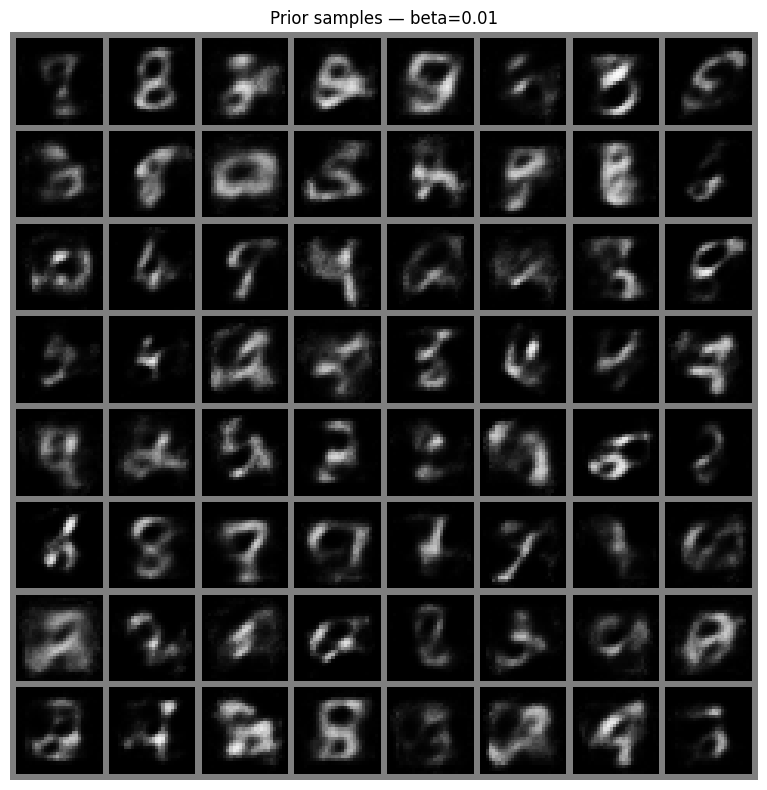

In [60]:
def sample_from_model(model, n_samples=64):
    model.eval()
    with torch.no_grad():
        z = torch.randn(n_samples, model.latent_dim, device=device)
        return model.decode(z).view(-1, 1, 28, 28).cpu()


# Train both models
higher_beta_model = VAE().to(device)
higher_beta_history_total, higher_beta_history_recon, higher_beta_history_kl = train_vae(higher_beta_model, train_loader, epochs=20, beta=8.0)

lower_beta_model = VAE().to(device)
lower_beta_history_total, lower_beta_history_recon, lower_beta_history_kl = train_vae(lower_beta_model, train_loader, epochs=20, beta=0.01)

# Plot loss curves side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(higher_beta_history_recon, label='Recon')
axes[0].plot(higher_beta_history_kl, label='KL')
axes[0].set_title('beta=8.0')
axes[0].legend()

axes[1].plot(lower_beta_history_recon, label='Recon')
axes[1].plot(lower_beta_history_kl, label='KL')
axes[1].set_title('beta=0.01')
axes[1].legend()
plt.tight_layout()
plt.show()

# Compare reconstructions of the same test digits
test_images, _ = next(iter(test_loader))
test_images = test_images[:16].to(device)

with torch.no_grad():
    high_recon, _, _ = higher_beta_model(test_images)
    low_recon, _, _ = lower_beta_model(test_images)

show_grid(test_images.cpu(), title="Original")
show_grid(high_recon.view(-1, 1, 28, 28).cpu(), title="Reconstructed — beta=8.0")
show_grid(low_recon.view(-1, 1, 28, 28).cpu(), title="Reconstructed — beta=0.01")

# Prior samples from both models
show_grid(sample_from_model(higher_beta_model), title="Prior samples — beta=8.0")
show_grid(sample_from_model(lower_beta_model), title="Prior samples — beta=0.01")

### 3.2 Reflect on the Effect of $\beta$ \[2 points\]

Answer the following questions after running the experiment:

1.  Which $\beta$ value produced better reconstructions in your short
    run, and which one pushed the latent distribution more strongly
    toward the prior? Explain how you can see this in the reconstruction
    plots and the KL curves.

2.  How does this experiment connect to the lecture discussion of
    latent-space structure, reconstruction quality, and blur?